# 01e — Confidence & Calibration

Logprobs aren't just for AUC / threshold tuning — they tell us **how sure the model is**.
This notebook is a *meta-analysis*: it reads `llm_calls.csv` (the per-call probability log
populated by 01a / 01b / 01d) plus the tuning-sample labels, and asks:

1. **Calibration** — when the model says 0.8, is it right ~80% of the time? (reliability diagram, ECE, Brier)
2. **Confidence vs correctness** — when it's *wrong*, is it confidently wrong (bad) or humbly wrong (good)?
3. **Confidence vs stability** — do the loans whose probability swings across runs (01b) sit near 0.5?
4. **Cross-model** — GPT-5.4 vs Gemini 2.5 Pro. *Anthropic exposes no logprobs → Claude is excluded (a finding in itself).*

**No new API calls, no cost.** It only reads what 01a / 01b / 01d already logged, so run it AFTER them.

In [1]:
# llm_utils lives one directory up.
import sys; sys.path.insert(0, "..")
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

from llm_utils import RESULTS_DIR, load_llm_sample, LLM_CALLS_PATH

## 1 — Load the per-call probability log and join ground-truth labels

In [2]:
# llm_calls.csv carries prob_fully_paid for every call across 01a/01b/01d.
# Join row_index -> tuning_sample label. (01a/01b/01d all score tuning_sample
# in the same order, so row_index is consistent across them.)
calls = pd.read_csv(LLM_CALLS_PATH)
sample = load_llm_sample()
y_by_index = sample['loan_status'].to_dict()   # row_index -> 0/1

# Calibrate only on experiments that scored the TUNING sample, so row_index maps
# to the right labels. This is an allow-list of the tuning-sample notebooks, which
# is safe by default: 01c (robustness_batch), 04 (test_batch) and 05 (robustness_batch)
# are excluded simply by not being listed, and any future notebook is excluded until
# added here. The 'new batch' guard also drops a held-out run that lives inside an
# otherwise-tuning notebook.
TUNING_NOTEBOOKS = [
    '01a_Model_Comparison.ipynb',
    '01b_Consistency.ipynb',
    '01d_reasoning_effort_runs.ipynb',
]
mask_tuning = (calls['notebook_id'].isin(TUNING_NOTEBOOKS)
               & ~calls['label'].str.contains('new batch', case=False, na=False))

df = calls[mask_tuning].copy()
df = df[df['prob_fully_paid'].notna()].copy()          # drops Anthropic (no logprobs)
df['y_true'] = df['row_index'].map(y_by_index)
df = df[df['y_true'].notna()].copy()
df['y_true']     = df['y_true'].astype(int)
df['p1']         = df['prob_fully_paid'].astype(float)  # P(Fully Paid = 1)
df['confidence'] = np.maximum(df['p1'], 1 - df['p1'])    # distance from 0.5, in [0.5, 1]
df['pred']       = (df['p1'] >= 0.5).astype(int)
df['correct']    = (df['pred'] == df['y_true']).astype(int)

HAVE_DATA = len(df) > 0
if not HAVE_DATA:
    print('No logprob rows found yet. Run 01a / 01b / 01d first, then re-run this notebook.')
else:
    print(f'{len(df)} logprob-bearing calls (tuning sample) from {df["model"].nunique()} model(s):')
    print(df.groupby(['provider', 'model']).size().to_string())

1000 logprob-bearing calls (tuning sample) from 2 model(s):
provider  model         
gemini    gemini-2.5-pro    200
openai    gpt-5.4           800


## 2 — Calibration: are the stated probabilities honest?

`ECE` = expected calibration error (lower is better, 0 = perfectly calibrated).
`Brier` = mean squared error of the probability (lower is better).

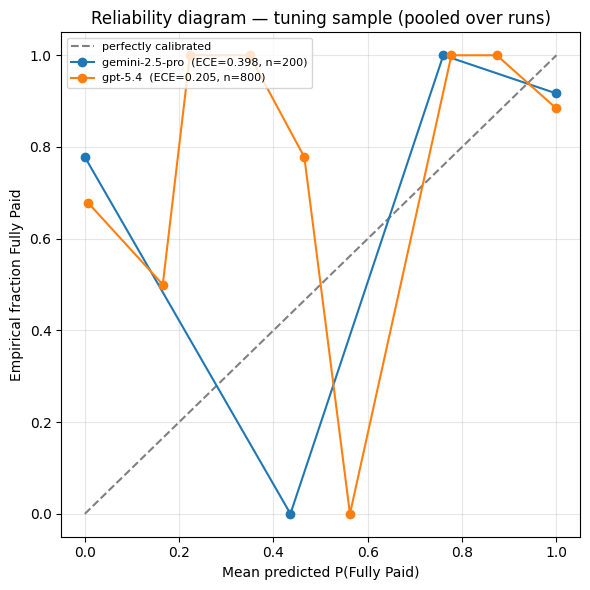

In [3]:
def ece_score(y, p, n_bins=10):
    """Expected Calibration Error with uniform bins."""
    y, p = np.asarray(y), np.asarray(p)
    edges = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(p, edges) - 1, 0, n_bins - 1)
    ece = 0.0
    for b in range(n_bins):
        m = idx == b
        if m.sum() == 0:
            continue
        ece += (m.sum() / len(p)) * abs(y[m].mean() - p[m].mean())
    return ece

def brier(y, p):
    return float(np.mean((np.asarray(p) - np.asarray(y)) ** 2))

if HAVE_DATA:
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.plot([0, 1], [0, 1], '--', color='gray', label='perfectly calibrated')
    for model, g in df.groupby('model'):
        if len(g) < 20:
            continue
        frac_pos, mean_pred = calibration_curve(g['y_true'], g['p1'], n_bins=10, strategy='uniform')
        ax.plot(mean_pred, frac_pos, marker='o',
                label=f"{model}  (ECE={ece_score(g['y_true'], g['p1']):.3f}, n={len(g)})")
    ax.set_xlabel('Mean predicted P(Fully Paid)')
    ax.set_ylabel('Empirical fraction Fully Paid')
    ax.set_title('Reliability diagram — tuning sample (pooled over runs)')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    os.makedirs(RESULTS_DIR, exist_ok=True)
    plt.savefig(f'{RESULTS_DIR}/01e_calibration.png', dpi=150)
    plt.show()

## 3 — Confidence vs correctness

If the model's mistakes cluster at **low** confidence, that's good news — its own
uncertainty flags the loans it's likely to get wrong. If mistakes happen at **high**
confidence, it's confidently wrong, which is the dangerous failure mode for a bank.

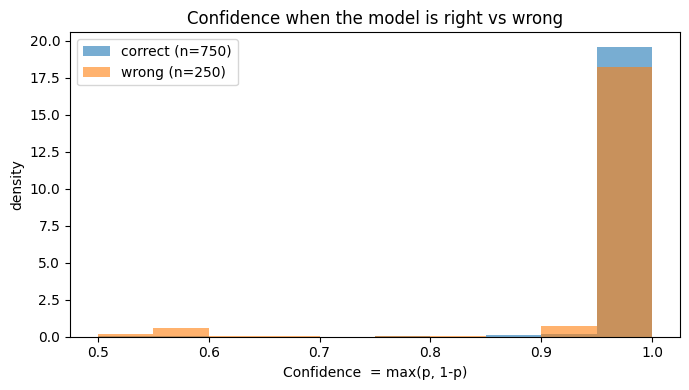

Mean confidence when CORRECT: 0.996
Mean confidence when WRONG:   0.976
Gap (correct - wrong):        +0.020  (positive = the model is less sure on its mistakes = good)


In [4]:
if HAVE_DATA:
    right = df[df['correct'] == 1]['confidence']
    wrong = df[df['correct'] == 0]['confidence']

    fig, ax = plt.subplots(figsize=(7, 4))
    bins = np.linspace(0.5, 1.0, 11)
    ax.hist(right, bins=bins, alpha=0.6, label=f'correct (n={len(right)})', density=True)
    ax.hist(wrong, bins=bins, alpha=0.6, label=f'wrong (n={len(wrong)})', density=True)
    ax.set_xlabel('Confidence  = max(p, 1-p)')
    ax.set_ylabel('density')
    ax.set_title('Confidence when the model is right vs wrong')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/01e_confidence_vs_correctness.png', dpi=150)
    plt.show()

    print(f'Mean confidence when CORRECT: {right.mean():.3f}')
    print(f'Mean confidence when WRONG:   {wrong.mean():.3f}')
    print(f'Gap (correct - wrong):        {right.mean() - wrong.mean():+.3f}  '
          '(positive = the model is less sure on its mistakes = good)')

## 4 — Confidence vs stability (the 01b link)

For loans scored in **multiple** runs (01b runs GPT-5.4 three times per condition),
compute the per-loan spread of P(Fully Paid). The hypothesis: loans with mean
confidence near 0.5 are the ones whose probability swings most across runs — i.e.
**confidence predicts instability**.

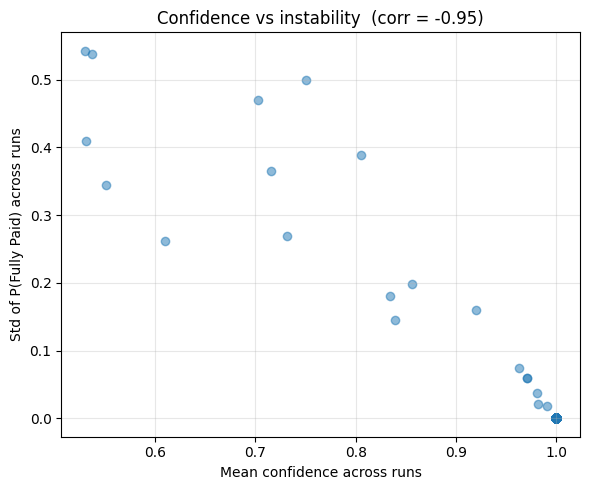

Correlation(mean confidence, run-to-run std) = -0.949
Negative => more confident loans are more stable (expected).


In [5]:
if HAVE_DATA:
    grp = (df.groupby(['model', 'desc_tag', 'row_index'])['p1']
             .agg(['mean', 'std', 'count']).reset_index())
    rep = grp[grp['count'] >= 2].copy()   # need repeated runs (01b)
    if len(rep) == 0:
        print('No loans have >=2 runs yet — run 01b (3 runs x 2 conditions) to populate this.')
    else:
        rep['mean_conf'] = np.maximum(rep['mean'], 1 - rep['mean'])
        corr = rep['mean_conf'].corr(rep['std'])
        fig, ax = plt.subplots(figsize=(6, 5))
        ax.scatter(rep['mean_conf'], rep['std'], alpha=0.5)
        ax.set_xlabel('Mean confidence across runs')
        ax.set_ylabel('Std of P(Fully Paid) across runs')
        ax.set_title(f'Confidence vs instability  (corr = {corr:+.2f})')
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig(f'{RESULTS_DIR}/01e_confidence_vs_stability.png', dpi=150)
        plt.show()
        print(f'Correlation(mean confidence, run-to-run std) = {corr:+.3f}')
        print('Negative => more confident loans are more stable (expected).')

## 5 — Cross-model summary + export

In [6]:
if HAVE_DATA:
    rows = []
    for model, g in df.groupby('model'):
        r = g[g['correct'] == 1]['confidence']
        w = g[g['correct'] == 0]['confidence']
        rows.append(dict(
            model=model, n=len(g),
            accuracy=g['correct'].mean(),
            brier=brier(g['y_true'], g['p1']),
            ece=ece_score(g['y_true'], g['p1']),
            mean_conf_correct=r.mean() if len(r) else np.nan,
            mean_conf_wrong=w.mean() if len(w) else np.nan,
        ))
    cal_table = pd.DataFrame(rows).set_index('model')
    cal_table['conf_gap'] = cal_table['mean_conf_correct'] - cal_table['mean_conf_wrong']
    print(cal_table.to_string(float_format=lambda x: f'{x:.4f}'))
    cal_table.to_csv(f'{RESULTS_DIR}/01e_confidence_metrics.csv')
    print(f'\nSaved 01e_confidence_metrics.csv (+ 3 PNGs) to {RESULTS_DIR}/')

                  n  accuracy  brier    ece  mean_conf_correct  mean_conf_wrong  conf_gap
model                                                                                    
gemini-2.5-pro  200    0.6050 0.3961 0.3983             0.9944           0.9998   -0.0054
gpt-5.4         800    0.7863 0.2024 0.2051             0.9962           0.9650    0.0312

Saved 01e_confidence_metrics.csv (+ 3 PNGs) to /Users/alemz/Projects/Github/Sabadell_Capstone/data/results/llm/


## How to read this for the presentation

- **Calibration (ECE / reliability diagram)** is the LLM-side answer to *"can we trust the
  number?"* — the quantitative complement to SHAP on the ML side. A well-calibrated LLM
  probability is as actionable as a PD from a scorecard.
- **Confidence-gap (correct − wrong)** turns into one sentence: *"the model is /less/ sure
  on the loans it gets wrong"* — evidence its uncertainty is meaningful.
- **Confidence ↔ stability** ties back to the brief's required **stability** metric: the
  flips in 01b aren't random, they're the low-confidence loans.
- **The routing hook:** if low-confidence calls are the unreliable ones, route *those* to
  XGBoost (or a human) and keep the confident LLM calls — the motivation for the hybrid phase.
- **Anthropic absence is a finding:** Claude can't be confidence-analyzed at all (no logprobs),
  which is itself relevant to a bank weighing providers on explainability.